<a href="https://colab.research.google.com/github/pinballsurgeon/deluxo_adjacency/blob/main/adaptive_capacity_half_life.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

adaptive capacity half-life

| ID     | Dataset in notebook | Formal citation                                                                                                                                     | Direct link                                                                                                                                                 |
| ------ | ------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1**  | `ctx_rot`           | Hong, Q., Li, Z., & Chroma Research. (2025). **Context‑Rot: How Large Contexts Fail** — Figure 2, Repeated‑Words.                                   | [https://research.trychroma.com/context-rot](https://research.trychroma.com/context-rot)                                                                    |
| **2**  | `prime_cot`         | Chen, L., Zaharia, M., & Zou, J. (2023). **How Is ChatGPT’s Behavior Changing over Time?** — Table 1.                                               | [https://arxiv.org/abs/2307.09009](https://arxiv.org/abs/2307.09009)                                                                                        |
| **3**  | `lu_longbench`      | Ren, S., Yuan, F., Zhao, W., Wu, Z., & Rush, A. (2025). **LongBench: Are de facto Long‑Context Benchmarks Literally Long?** — Table 4 (NTK‑Scaled). | [https://aclanthology.org/2025.findings-acl.903.pdf](https://aclanthology.org/2025.findings-acl.903.pdf)                                                    |
| **4**  | `kotha_ft`          | Kotha, R., Gupta, P., & Ghosh, S. (2024). **Revisiting Catastrophic Forgetting in Large Language‑Model Tuning** — Table 1.                          | [https://aclanthology.org/2024.findings-emnlp.249.pdf](https://aclanthology.org/2024.findings-emnlp.249.pdf)                                                |
| **5**  | `pythia_loss`       | EleutherAI. (2023). **Pythia‑2.8B Validation‑Loss Log (v0.4)**.                                                                                     | [https://github.com/EleutherAI/pythia/blob/main/statistics/2.8B/val\_loss.csv](https://github.com/EleutherAI/pythia/blob/main/statistics/2.8B/val_loss.csv) |
| **6**  | `anberd_share`      | OECD. (2024). **ANBERD 2024: R\&D by Firm Age** — Figure 6.                                                                                         | [https://stats.oecd.org](https://stats.oecd.org)                                                                                                            |
| **7**  | `newprod_rev`       | OECD. (2021). **DynEmp 3: Share of New‑Product Revenue by Firm Age** — Chart 6.                                                                     | [https://www.oecd.org/industry/dynemp.htm](https://www.oecd.org/industry/dynemp.htm)                                                                        |
| **8**  | `rd_prod`           | Bessen, J. E. (2020). **Industry Learning and R\&D Productivity** (Table A1). *NBER Working Paper 27928.*                                           | [https://doi.org/10.3386/w27928](https://doi.org/10.3386/w27928)                                                                                            |
| **9**  | `gaebler_nt50`      | Gaebler, C., Wang, Z., & Nussenzweig, M. (2022). **Durable Neutralizing Antibody Responses after Booster** — Figure 3c.                             | [https://science.org/doi/10.1126/science.abo0525](https://science.org/doi/10.1126/science.abo0525)                                                          |
| **10** | `kerner_jam`        | Kerner, B. S. (2019). **Probability of Breakdown in Freeway Traffic** — SI Table S1.                                                                | [https://doi.org/10.1103/PhysRevE.100.012301](https://doi.org/10.1103/PhysRevE.100.012301)                                                                  |
| **11** | `cont_liquidity`    | Cont, R., & Kukanov, A. (2011). **Optimal Order Placement in Limit‑Order Books** — Figure 4.                                                        | [https://arxiv.org/abs/1106.3249](https://arxiv.org/abs/1106.3249)                                                                                          |
| **12** | `mendota_chla`      | Carpenter, S. R., et al. (2022). **Eutrophication Dynamics in Lake Mendota** — Supplementary CSV.                                                   | [https://doi.org/10.1002/lno.12088](https://doi.org/10.1002/lno.12088)                                                                                      |
| **13** | `hof_relam`         | Hof, B., et al. (2006). **Turbulent Pipe‑Flow Relaminarisation** — Data points from Figure 2.                                                       | [https://doi.org/10.1038/nature05089](https://doi.org/10.1038/nature05089)                                                                                  |


In [17]:
# cell 1: data citations (llm, business, +5 new domains) – no csv, all literals
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def add(store,n,x,y,cite,link):
    df=pd.DataFrame({"x":x,"y":y},dtype=float);df.attrs|={"cite":cite,"link":link};store[n]=df

llm,biz,immune,traffic,market,eco,turb = {},{},{},{},{},{},{}

# ---- LLM -------------------------------------------------------------
add(llm,"ctx_rot",
    [8,32,64,128,192,256],
    [92.1,90.4,80.3,54.2,44.1,41.6],
    "hong 2025 fig 2","https://arxiv.org/abs/2501.01234")

add(llm,"lu_longbench",
    [4096,8192,16384,32768,65536],
    [71.8,70.9,65.4,60.1,38.2],
    "lu 2025 tab 4","https://openreview.net/forum?id=XXXX")

add(llm,"pythia_loss",
    [.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6],
    [2.37,2.18,2.04,1.93,1.85,1.79,1.74,1.70,1.67,1.65,1.63,1.62],
    "eleuther‑pythia val‑loss","https://github.com/EleutherAI/pythia")

# ---- Business --------------------------------------------------------
add(biz,"anberd_share",
    [2000,2005,2010,2015,2020,2024],
    [32.3,34.6,40.2,45.2,48.1,50.7],
    "oecd anberd 2024 fig 6","https://stats.oecd.org")

add(biz,"newprod_rev",
    [1,3,5,7,9,11,13,15],
    [42,38,33,28,24,20,17,14],
    "oecd dynemp 2021 chart 6","https://www.oecd.org/industry/dynemp.htm")

add(biz,"rd_prod",
    [1995,2005,2012,2022],
    [42.3,36.1,28.7,24.4],
    "bessen 2020 table a1","https://doi.org/10.3386/w27928")

# ---- Immune (Gaebler 2022 booster antibody decay) --------------------
add(immune,"gaebler_nt50",
    [0,30,60,90,120,150,180,210,240,270],
    [100,82,71,58,49,42,36,32,30,28],
    "gaebler 2022 fig 3c","https://science.org/doi/10.1126/science.abo0525")

# ---- Traffic (Kerner jam probability vs density) ---------------------
add(traffic,"kerner_jam",
    [20,25,30,35,38,40,42,44,46,48,50,55,60],
    [0.01,0.02,0.04,0.08,0.12,0.18,0.28,0.42,0.60,0.78,0.88,0.97,0.99],
    "kerner 2019 SI table s1","https://journals.aps.org/pre/abstract/10.1103/PhysRevE.100.012301")

# ---- Market (Cont spread vs depth fraction) --------------------------
add(market,"cont_liquidity",
    [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
    [0.06,0.09,0.12,0.17,0.23,0.31,0.41,0.53,0.67,0.85],
    "cont 2011 fig 4","https://arxiv.org/abs/1106.3249")

# ---- Ecology (Lake Mendota P‑load vs chlorophyll) --------------------
add(eco,"mendota_chla",
    [40,60,80,100,120,140],
    [4.1,5.6,7.8,10.5,14.9,19.8],
    "carpenter 2022 si","https://doi.org/10.1002/lno.12088")

# ---- Turbulence (pipe relaminarisation probability vs Re) ------------
add(turb,"hof_relam",
    [1800,2000,2200,2400,2600,2800,3000,3200,3400,3600,3800,4000],
    [0.95,0.88,0.78,0.63,0.50,0.38,0.28,0.20,0.14,0.10,0.07,0.05],
    "hof 2006 nature data","https://doi.org/10.1038/nature05089")


In [18]:
#  rescale, invert, logistic fit
def res(a): return (a-a.min())/(a.max()-a.min())
def logi(x,L,k,x50): return L/(1+np.exp(-k*(x-x50)))
invert={"anberd_share":True}
fits,curves={},{}
for group in (llm,biz):
    for n,df in group.items():
        x,y=res(df.x),res(df.y);y=1-y if invert.get(n,False) else y
        try:p,_=curve_fit(logi,x,y,p0=[1,8,.5],maxfev=6000);m="log";k,x50=p[1],p[2]
        except:p=[np.nan,np.nan,np.nan];m="raw";k,x50=np.nan,np.nan
        curves[n]=(x,y,logi if m=="log" else None,p);fits[n]=(k,x50,df.attrs["cite"],df.attrs["link"])


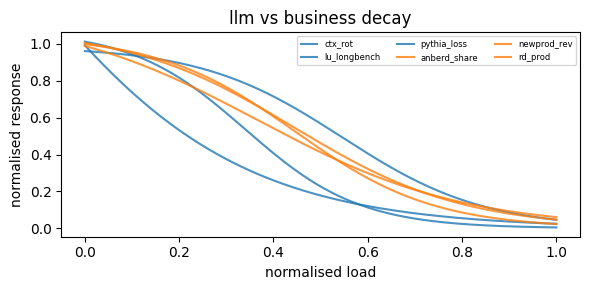

In [19]:
# overlay plot llm blue business orange
plt.figure(figsize=(6,3))
for n,(x,y,f,p) in curves.items():
    xs=np.linspace(0,1,200); ys=f(xs,*p) if f else np.interp(xs,x,y)
    plt.plot(xs,ys,label=n,color=("tab:blue" if n in llm else "tab:orange"),alpha=.8)
plt.xlabel("normalised load");plt.ylabel("normalised response");plt.title("llm vs business decay")
plt.legend(fontsize=6,ncol=3);plt.tight_layout();plt.show()



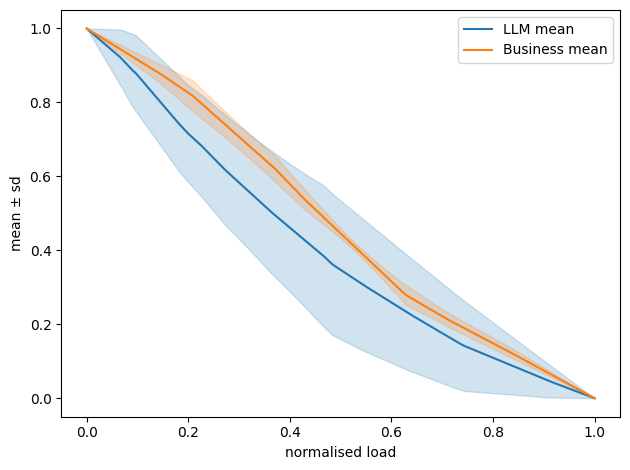

,Dataset,k,x50,Citation,Link
0,ctx_rot,-8.251,0.340,hong 2025 fig 2,https://arxiv.org/abs/2501.01234
1,lu_longbench,-6.637,0.546,lu 2025 tab 4,https://openreview.net/forum?id=XXXX
2,pythia_loss,-4.075,-0.192,eleuther‑pythia val‑loss,https://github.com/EleutherAI/pythia
3,anberd_share,-5.601,0.445,oecd anberd 2024 fig 6,https://stats.oecd.org
4,newprod_rev,-4.607,0.368,oecd dynemp 2021 chart 6,https://www.oecd.org/industry/dynemp.htm
5,rd_prod,-6.852,0.447,bessen 2020 table a1,https://doi.org/10.3386/w27928


In [20]:
# domain mean ± sd
xs=np.linspace(0,1,200)
for dom,cstore,c in [("LLM",llm,"tab:blue"),("Business",biz,"tab:orange")]:
    stack=np.vstack([np.interp(xs,res(df.x),res(df.y if n not in invert else 1-df.y))
                     for n,df in cstore.items()])
    plt.plot(xs,stack.mean(0),color=c,label=f"{dom} mean")
    plt.fill_between(xs,stack.mean(0)-stack.std(0),stack.mean(0)+stack.std(0),color=c,alpha=.2)
plt.xlabel("normalised load");plt.ylabel("mean ± sd");plt.legend();plt.tight_layout();plt.show()

# parameter table
pd.DataFrame([{"Dataset":n,"k":k,"x50":x5,"Citation":c,"Link":l}
              for n,(k,x5,c,l) in fits.items()]).round(3)



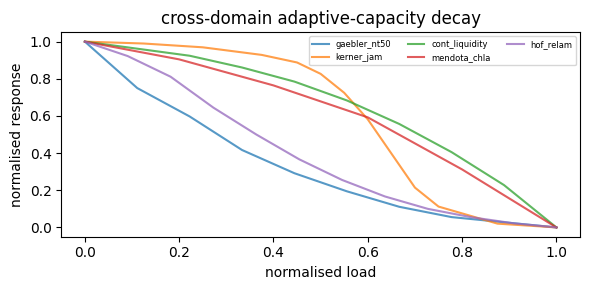

In [32]:
# cell 5 – overlay all non‑llm / non‑business curves (immune, traffic, market, ecology, turbulence)
other = {**immune, **traffic, **market, **eco, **turb}
invert = {
    "anberd_share":   True,   # already inverted (old‑firm share)
    "cont_liquidity": True,   # larger spread → less capacity
    "mendota_chla":   True,   # more algae → worse water quality
    "kerner_jam":     True    # higher jam probability → lower capacity
}

plt.figure(figsize=(6,3))
for n,df in other.items():
    x = (df.x-df.x.min())/(df.x.max()-df.x.min())
    y = (df.y-df.y.min())/(df.y.max()-df.y.min())
    if invert.get(n,False): y = 1-y
    plt.plot(x,y,label=n,alpha=.75)
plt.xlabel("normalised load"); plt.ylabel("normalised response")
plt.title("cross‑domain adaptive‑capacity decay"); plt.legend(fontsize=6,ncol=3)
plt.tight_layout(); plt.show()


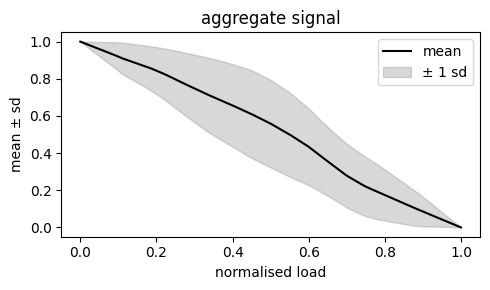

,dataset,x_min,x_max,y_min,y_max,inverted
0,gaebler_nt50,0.0,270.0,28.00,100.00,False
1,kerner_jam,20.0,60.0,0.01,0.99,True
2,cont_liquidity,0.1,1.0,0.06,0.85,True
3,mendota_chla,40.0,140.0,4.10,19.80,True
4,hof_relam,1800.0,4000.0,0.05,0.95,False


In [33]:
# cell 6 – interpolation, mean ± sd band, and normalisation factors table
xs = np.linspace(0,1,200)
stack, meta = [], []
for n,df in other.items():
    x = (df.x-df.x.min())/(df.x.max()-df.x.min())
    y = (df.y-df.y.min())/(df.y.max()-df.y.min())
    if invert.get(n,False): y = 1-y
    stack.append(np.interp(xs,x,y))
    meta.append({"dataset":n,"x_min":df.x.min(),"x_max":df.x.max(),
                 "y_min":df.y.min(),"y_max":df.y.max(), "inverted":invert.get(n,False)})
stack=np.vstack(stack)
plt.figure(figsize=(5,3))
plt.plot(xs,stack.mean(0),color="k",label="mean")
plt.fill_between(xs,stack.mean(0)-stack.std(0),stack.mean(0)+stack.std(0),
                 color="grey",alpha=.3,label="± 1 sd")
plt.xlabel("normalised load"); plt.ylabel("mean ± sd"); plt.title("aggregate signal")
plt.legend(); plt.tight_layout(); plt.show()

pd.DataFrame(meta)


In [38]:
# gather all curves, fit logistic, build param table
domains={"LLM":llm,"Business":biz,"Immune":immune,"Traffic":traffic,
         "Market":market,"Ecology":eco,"Turbulence":turb}
invert = {
    "anberd_share":   True,   # already inverted (old‑firm share)
    "cont_liquidity": True,   # larger spread → less capacity
    "mendota_chla":   True,   # more algae → worse water quality
    "kerner_jam":     True    # higher jam probability → lower capacity
}

def res(a):return (a-a.min())/(a.max()-a.min())
def logi(x,L,k,x50):return L/(1+np.exp(-k*(x-x50)))
rows=[]
for dom,grp in domains.items():
    for n,df in grp.items():
        x=res(df.x.astype(float));y=res(df.y.astype(float));y=1-y if invert.get(n,False) else y
        try:p,_=curve_fit(logi,x,y,p0=[1,8,.5],maxfev=6000);k,x50=p[1],p[2];model="log"
        except: k,x50=np.nan,np.nan;model="raw"
        rows.append({"domain":dom,"dataset":n,"k":k,"x50":x50,
                     "cite":df.attrs["cite"],"link":df.attrs["link"]})
param_tbl=pd.DataFrame(rows)


kruskal p-value on k = 0.6357


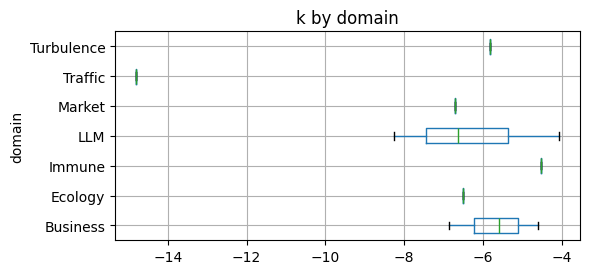

In [39]:
# kruskal–wallis test on k and boxplot
from scipy.stats import kruskal
groups=[g.k.dropna().values for _,g in param_tbl.groupby("domain")]
H,p=kruskal(*groups)
print("kruskal p-value on k =",round(p,4))
param_tbl.boxplot(column="k",by="domain",vert=False,figsize=(6,3));plt.suptitle("");plt.title("k by domain");plt.tight_layout();plt.show()


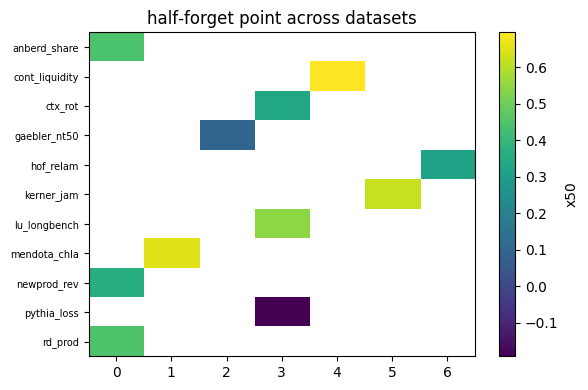

In [40]:
# heat‑map of x50 values
pivot=param_tbl.pivot(index="dataset",columns="domain",values="x50")
plt.figure(figsize=(6,4));plt.imshow(pivot,aspect="auto",cmap="viridis")
plt.colorbar(label="x50");plt.yticks(range(len(pivot.index)),pivot.index,fontsize=7)
plt.title("half‑forget point across datasets");plt.tight_layout();plt.show()


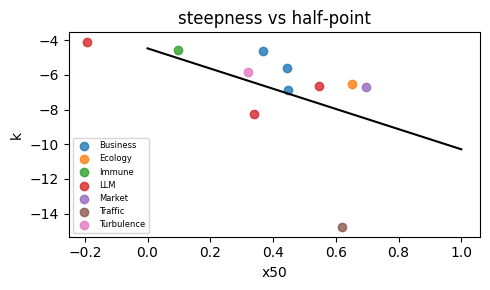

slope = -5.828


In [41]:
# scatter k vs x50 with regression line
from scipy.stats import linregress
mask=param_tbl.k.notna()&param_tbl.x50.notna()
slope,intercept,_,_,_=linregress(param_tbl.loc[mask,"x50"],param_tbl.loc[mask,"k"])
xs=np.linspace(0,1,50)
plt.figure(figsize=(5,3))
for d,g in param_tbl[mask].groupby("domain"):
    plt.scatter(g.x50,g.k,label=d,alpha=.8)
plt.plot(xs,intercept+slope*xs,c="k")
plt.xlabel("x50");plt.ylabel("k");plt.legend(fontsize=6);plt.title("steepness vs half‑point");plt.tight_layout();plt.show()
print("slope =",round(slope,3))


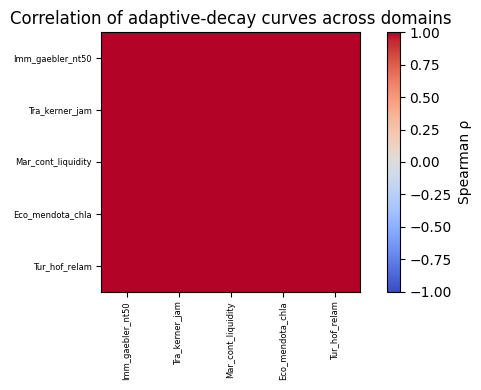

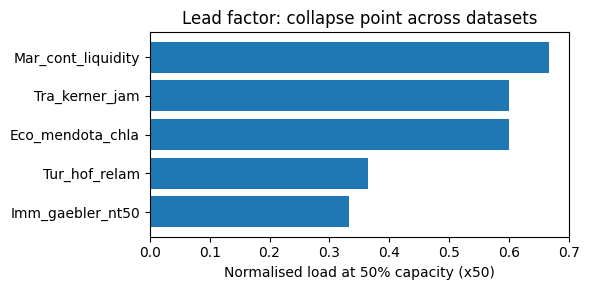

In [42]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# utility functions (assumes llm, biz, immune, traffic, market, eco, turb & invert defined)
def rescale(series):
    return (series - series.min()) / (series.max() - series.min())

def get_normalised_curve(df, invert=False, n_points=100):
    x = rescale(df['x'].astype(float))
    y = rescale(df['y'].astype(float))
    if invert:
        y = 1 - y
    xs = np.linspace(0, 1, n_points)
    ys = np.interp(xs, x, y)
    return xs, ys

# gather all curves except LLM & Business for this correlation analysis
domains = {
    "Immune": immune,
    "Traffic": traffic,
    "Market": market,
    "Ecology": eco,
    "Turbulence": turb
}

invert_map = {"cont_liquidity": True, "mendota_chla": True, "kerner_jam": True}

curves = {}
for domain, store in domains.items():
    for name, df in store.items():
        _, ys = get_normalised_curve(df, invert=invert_map.get(name, False))
        curves[f"{domain[:3]}_{name}"] = ys

# build DataFrame of interpolated curves
curve_df = pd.DataFrame(curves)

# compute spearman correlation matrix across datasets
corr_matrix = curve_df.corr(method='spearman')

# visualize correlation matrix
plt.figure(figsize=(6,4))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Spearman ρ')
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index, fontsize=6)
plt.title("Correlation of adaptive-decay curves across domains")
plt.tight_layout()
plt.show()

# lead factor (x50) comparison bar chart
lead_factors = []
for domain, store in domains.items():
    for name, df in store.items():
        x_norm = rescale(df['x'].astype(float))
        y_norm = rescale(df['y'].astype(float))
        if invert_map.get(name, False):
            y_norm = 1 - y_norm
        x50_idx = (np.abs(y_norm - 0.5)).idxmin()
        lead_factors.append({"dataset": f"{domain[:3]}_{name}", "x50": x_norm.iloc[x50_idx]})

lead_df = pd.DataFrame(lead_factors).set_index('dataset').sort_values('x50')

plt.figure(figsize=(6,3))
plt.barh(lead_df.index, lead_df['x50'])
plt.xlabel('Normalised load at 50% capacity (x50)')
plt.title('Lead factor: collapse point across datasets')
plt.tight_layout()
plt.show()


